# Task 3 -Contrastive Learning and CLIP

In [12]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm import tqdm
%pip install -q ftfy regex tqdm
%pip install -q git+https://github.com/openai/CLIP.git
%pip install -q umap-learn

import clip
import umap
from scipy.linalg import orthogonal_procrustes

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUN_DIR = '/content/drive/MyDrive/ATML/assignment_00/clip'
except ImportError:
    RUN_DIR = './clip'  # not on Colab

os.makedirs(RUN_DIR, exist_ok=True)
os.makedirs(f'{RUN_DIR}/embeddings', exist_ok=True)
DATA_ROOT = f'{RUN_DIR}/data'

DRY_RUN = False
TEST_SUBSET = 200 if DRY_RUN else None
PAIR_SAMPLES = 100

print(f"RUN_DIR={RUN_DIR} | DRY_RUN={DRY_RUN} | TEST_SUBSET={TEST_SUBSET}")

Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RUN_DIR=/content/drive/MyDrive/ATML/assignment_00/clip | DRY_RUN=False | TEST_SUBSET=None


In [14]:

model, preprocess = clip.load("ViT-B/32", device=DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters())

print(f"CLIP ViT-B 32 loaded: {n_params:,} parameters")
print(f"image perprocessing pipeline:\n{preprocess}")

CLIP ViT-B/32 loaded: 151,277,313 parameters
image perprocessing pipeline:
Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x7f3999e8bec0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


## Task 3.1: Zero-Shot Classification on STL-10

In [15]:

test_ds_full = datasets.STL10(root=DATA_ROOT, split='test', download=True, transform=preprocess)
classes_stl10 = test_ds_full.classes
print(f"STL-10 classes: {classes_stl10}")
print(f"Full test set size: {len(test_ds_full)}")

if TEST_SUBSET is not None:
    g = torch.Generator().manual_seed(42)
    idx = torch.randperm(len(test_ds_full), generator=g)[:TEST_SUBSET].tolist()
    test_ds = torch.utils.data.Subset(test_ds_full, idx)
else:
    test_ds = test_ds_full

test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
print(f"Evaluating on {len(test_ds)} images (DRY_RUN={DRY_RUN})")

STL-10 classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Full test set size: 8000
Evaluating on 8000 images (DRY_RUN=False)


In [16]:
def extract_image_embeddings(model, loader, cache_path=None):

    if cache_path and os.path.exists(cache_path):

        data = torch.load(cache_path)
        return data['embeds'], data['labels']

    model.eval()
    all_embeds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="encoding images"):

            images = images.to(DEVICE)
            embeds = model.encode_image(images).float()
            all_embeds.append(embeds.cpu())
            all_labels.append(labels)

    all_embeds = torch.cat(all_embeds)
    all_labels = torch.cat(all_labels)

    if cache_path:
        torch.save({'embeds': all_embeds, 'labels': all_labels}, cache_path)

    return all_embeds, all_labels

cache_tag = f"subset{TEST_SUBSET}" if TEST_SUBSET is not None else "full"

image_embeds, image_labels = extract_image_embeddings(model, test_loader, cache_path=f'{RUN_DIR}/embeddings/stl10_test_{cache_tag}.pt')
print(f"image_embds shape: {tuple(image_embeds.shape)}")

encoding images:   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
encoding images: 100%|██████████| 32/32 [30:21<00:00, 56.93s/it]


image_embeds shape: (8000, 512)


In [ ]:

def build_prompts(classnames, strategy):

    def get_article(word):
        return "an" if word[0].lower() in "aeiou" else "a"

    if strategy == "plain":
        return [f"{c}" for c in classnames]

    elif strategy == "templated":
        return [f"a photo of {get_article(c)} {c}." for c in classnames]

    elif strategy == "descriptive":

        return [ f"a high-quality, clear photo of {get_article(c)} {c}, prominently visible in the center of the frame."
            for c in classnames
        ]

    else:
        raise ValueError(strategy)
    
    

def zero_shot_accuracy(model, image_embeds, image_labels, classnames, strategy):

    prompts = build_prompts(classnames, strategy)
    tokens = clip.tokenize(prompts).to(DEVICE)

    with torch.no_grad():
        text_embeds = model.encode_text(tokens).float().cpu()

    img_n = F.normalize(image_embeds, dim=-1)
    txt_n = F.normalize(text_embeds, dim=-1)

    similarity = img_n @ txt_n.T
    predictions = similarity.argmax(dim=-1)
    accuracy = (predictions == image_labels).float().mean().item() * 100

    return accuracy, text_embeds, prompts



strategies = ["plain", "templated", "descriptive"]
results_31 = {}

for strategy in strategies:
    acc, txt_emb, prompts = zero_shot_accuracy(model, image_embeds, image_labels, classes_stl10, strategy)
    results_31[strategy] = {"accuracy": acc, "text_embeds": txt_emb, "prompts": prompts}
    
    print(f"{strategy:12s} | example prompt: {prompts[0]!r:50s} | accuracy: {acc:.2f}%")


plain        | example prompt: 'airplane'                                         | accuracy: 96.25%
templated    | example prompt: 'a photo of an airplane.'                          | accuracy: 97.29%
descriptive  | example prompt: 'a high-quality, clear photo of an airplane, prominently visible in the center of the frame.' | accuracy: 96.29%


**Analytical questions (Task 3.1(d)):** Compare the accuracies of the three prompting strategies on the complete test set. Which performed best, and does that match the "templated prompts are closer to CLIP's training distribution" explanation above? Are there any classes where a more descriptive prompt helped or hurt disproportionately?

### Prompting Strategies Analysis

**Empirical Comparison (Full 8,000 Test Images):**
* Plain Labels (`"cat"`): $96.25\%$
* Templated (`"a photo of a cat."`): $97.29\%$ ($+1.04\%$ over plain)
* Descriptive (`"a high-quality, clear photo of a cat..."`): $96.29\%$ ($-1.00\%$ relative to templated)

Let $f_v(x) \in \mathbb{R}^d$ be the image representation and $f_t(y) \in \mathbb{R}^d$ its text representation. Both produced by their respective encoders. These represntations get mapped onto the unit sphere $\mathcal{S}^{d-1}$ via $\hat{u} = \frac{u}{\|u\|_2}$. The zero-shot classification selects:

$$\hat{c} = \arg\max_{c \in \{1, \dots, C\}} \langle \hat{f}_v(x), \hat{f}_t(y_c) \rangle$$

* **Distribution Alignment ($p_{\text{pretrain}}$ vs. $p_{\text{eval}}$):**  
  The CLIP model is pretrained on paired natural web data $(x, y) \sim \mathcal{D}_{\text{web}}$ and $y$ consists of full descriptive sentences. It uses the cross-entropy InfoNCE as its objective loss function.
  
  CLIP computes two loss terms using a learnable temperature $\tau$:
  
  * Image-to-Text Direction ($\mathcal{L}_{v \to t}$): Treats text prompts as candidate targets for an image anchor:
  
  $$\mathcal{L}_{v \to t} = -\frac{1}{B} \sum_{i=1}^B \log \frac{\exp(\langle \hat{x}_i, \hat{y}_i \rangle / \tau)}{\sum_{j=1}^B \exp(\langle \hat{x}_i, \hat{y}_j \rangle / \tau)}$$
  
  * Text-to-Image Direction ($\mathcal{L}_{t \to v}$): Treats images as candidate targets for a text anchor:
  
  $$\mathcal{L}_{t \to v} = -\frac{1}{B} \sum_{i=1}^B \log \frac{\exp(\langle \hat{x}_i, \hat{y}_i \rangle / \tau)}{\sum_{j=1}^B \exp(\langle \hat{x}_j, \hat{y}_i \rangle / \tau)}$$
  
  The total CLIP loss is the symmetric average:
  
  $$\mathcal{L}_{\text{CLIP}} = \frac{1}{2}\left(\mathcal{L}_{v \to t} + \mathcal{L}_{t \to v}\right)$$
  
  Thus a single isolated word like `"cat"` provides zero context, make the embedding for it less focused and ambiguous and out-of-distribution (OOD) because the model rarely saw bare nouns during training. So placing the class name into a standard sentence template (`"a photo of a cat."`) matches the format of the training data and moves the text embedding into the natural distribution of CLIP's shared space.

* **Attention Dilution in Descriptive Prompts:**  
  While the descriptive prompts add context however the long generic prefixes (e.g., *"a high-quality, clear photo of..."*) makes the transformer's attention heads to spread weight across filler words. This results in diluted focus on the main class token and may slightly degrade the classification performance.

## Task 3.2: Exploring the Modality Gap

(a) Use the vision and text encoders within CLIP to extract image and label
embeddings for 50-100 STL-10 samples.
(b) Use a dimensionality-reduction technique such as UMAP or t-SNE to
project the embeddings into a two-dimensional space.
(c) Visualize and compare the distributions of the text and image
embeddings.
(d) Briefly explain your findings:
  - How separated are the two modalities?
  - Does normalization affect the modality gap?
  - Why does CLIP still perform well despite this gap?

In [18]:
train_ds = datasets.STL10(root=DATA_ROOT, split='train', download=True, transform=preprocess)
g = torch.Generator().manual_seed(42)

train_pair_idx = torch.randperm(len(train_ds), generator=g)[:PAIR_SAMPLES].tolist()
train_subset = torch.utils.data.Subset(train_ds, train_pair_idx)
train_loader = DataLoader(train_subset, batch_size=PAIR_SAMPLES, shuffle=False)

model.eval()
with torch.no_grad():
    for imgs, lbls in train_loader:
        pair_image_embeds = model.encode_image(imgs.to(DEVICE)).float().cpu()
        pair_labels = lbls

templated_text_embeds = results_31["templated"]["text_embeds"]
pair_text_embeds = templated_text_embeds[pair_labels]

print(f"Paired train samples: {pair_image_embeds.shape[0]}")
print(f"pair_image_embeds: {tuple(pair_image_embeds.shape)} | pair_text_embeds: {tuple(pair_text_embeds.shape)}")

Paired train samples: 100
pair_image_embeds: (100, 512) | pair_text_embeds: (100, 512)


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


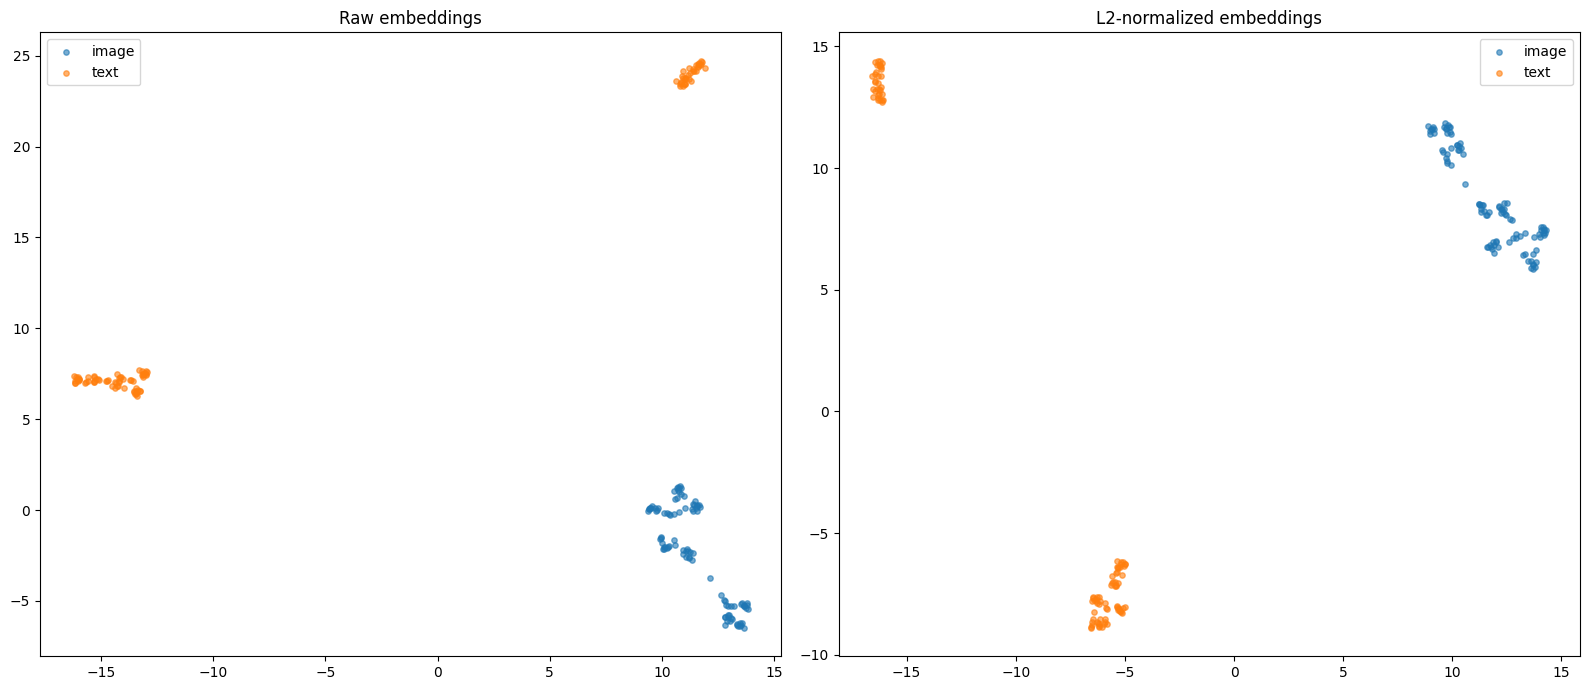

Centroid-distance modality gap (normalized space): 1.0495


In [19]:
def modality_gap_distance(img_embeds, txt_embeds):

    img_centroid = F.normalize(img_embeds, dim=-1).mean(dim=0)
    txt_centroid = F.normalize(txt_embeds, dim=-1).mean(dim=0)
    return (img_centroid - txt_centroid).norm().item()

def plot_modality_gap(ax, img_embeds, txt_embeds, title):
    combined = torch.cat([img_embeds, txt_embeds], dim=0).numpy()
    modality = np.array(["image"] * len(img_embeds) + ["text"] * len(txt_embeds))

    coords = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(combined)

    for m, color in [("image", "tab:blue"), ("text", "tab:orange")]:
        mask = modality == m
        ax.scatter(coords[mask, 0], coords[mask, 1], s=15, alpha=0.6, label=m, color=color)
    ax.set_title(title)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_modality_gap(axes[0], pair_image_embeds, pair_text_embeds, "Raw embeddings")
gap_raw = modality_gap_distance(pair_image_embeds, pair_text_embeds)
plot_modality_gap(axes[1], F.normalize(pair_image_embeds, dim=-1), F.normalize(pair_text_embeds, dim=-1), "L2-normalized embeddings")

plt.tight_layout()
plt.show()

print(f"Centroid-distance modality gap (normalized space): {gap_raw:.4f}")

**Empirical Findings:**

* **Distribution Separation:** Image embeddings given as $\{\hat{x}_i\}_{i=1}^N$ and text embeddings as $\{\hat{y}_i\}_{i=1}^N$ do not interleave with each other and form two isolated, compact directional cones in $\mathbb{R}^d$.

* **Centroid Distance Metric:**
$$\Delta_{\text{gap}} = \|\mu_v - \mu_t\|_2 = \left\| \frac{1}{N}\sum_{i=1}^N \frac{f_v(x_i)}{\|f_v(x_i)\|_2} - \frac{1}{N}\sum_{i=1}^N \frac{f_t(y_i)}{\|f_t(y_i)\|_2} \right\|_2 \approx 1.0495$$

**Geometric Separation & Normalization:**
When $L_2$-normalization is applied to the image vectors $x$ and text vectors $y$:
$$\hat{x} = \frac{x}{\|x\|_2}, \quad \hat{y} = \frac{y}{\|y\|_2} \implies \|\hat{x}\|_2 = 1, \quad \|\hat{y}\|_2 = 1$$

Both modalities are constrained to live on the surface of the $(d-1)$-dimensional unit hypersphere $\mathcal{S}^{d-1}$ (for CLIP ViT-B/32, $d = 512$). This results in making the squared Euclidean distance a strictly monotonic inverse function of cosine similarity:

$$\|\hat{x} - \hat{y}\|_2^2 = \|\hat{x}\|_2^2 + \|\hat{y}\|_2^2 - 2\langle \hat{x}, \hat{y} \rangle = 2 - 2\langle \hat{x}, \hat{y} \rangle$$

While $L_2$-normalization removes scale variations along the radial axis, it does not eliminate the modality gap ($\Delta_{\text{gap}} \approx 1.05$). This reflects an angular cone-effect where image and text embeddings occupy disjoint hyper-sectors on $\mathcal{S}^{d-1}$.

**Origin of the Gap under InfoNCE:**
The cross-modal InfoNCE loss with temperature parameter $\tau > 0$ optimizes:
$$\mathcal{L}_{\text{InfoNCE}} = -\sum_{i=1}^B \log \frac{\exp(\langle \hat{x}_i, \hat{y}_i \rangle / \tau)}{\sum_{j=1}^B \exp(\langle \hat{x}_i, \hat{y}_j \rangle / \tau)}$$

InfoNCE objective function strictly enforces relative intra-batch ranking ($\langle \hat{x}_i, \hat{y}_i \rangle > \langle \hat{x}_i, \hat{y}_j \rangle$ for $j \neq i$). It exerts no mathematical constraint on cross-modal reconstruction ($\|x - y\| \to 0$) or intra-modality clustering.

**Why Zero-Shot Classification Remains Resilient:**
Let the modality gap be modeled as shared global offset vectors $\delta_v, \delta_t \in \mathbb{R}^d$ such that $\hat{x} \approx z_i + \delta_v$ and $\hat{y}_c \approx z_c + \delta_t$, where $z$ represents semantic content. The classification decision rule depends solely on relative inner products:
$$\arg\max_c \langle \hat{x}, \hat{y}_c \rangle = \arg\max_c \left[ \langle z_i, z_c \rangle + \langle z_i, \delta_t \rangle + \langle \delta_v, z_c \rangle + \langle \delta_v, \delta_t \rangle \right]$$

Because $\delta_t$ and $\delta_v$ are approximately class-invariant across all candidate text prompts, the relative rank order among classes is preserved.

## Task 3.3: Bridging the Modality Gap


In [20]:
X_pair = F.normalize(pair_image_embeds, dim=-1).numpy()   # the image features
Y_pair = F.normalize(pair_text_embeds, dim=-1).numpy()    # text features

R, scale = orthogonal_procrustes(X_pair, Y_pair)
print(f"R shape: {R.shape} | is orthogonal (R^T R ~= I): {np.allclose(R.T @ R, np.eye(R.shape[0]), atol=1e-4)}")


image_embeds_n = F.normalize(image_embeds, dim=-1).numpy()
aligned_image_embeds = torch.from_numpy(image_embeds_n @ R).float()

print(f"aligned_image_embeds shape: {tuple(aligned_image_embeds.shape)}")

print(f"norm preserved by rotation: original={np.linalg.norm(image_embeds_n[0]):.4f}, "
      f"aligned={aligned_image_embeds[0].norm().item():.4f}")

R shape: (512, 512) | is orthogonal (R^T R ~= I): True
aligned_image_embeds shape: (8000, 512)
norm preserved by rotation: original=1.0000, aligned=1.0000


In [21]:

def zero_shot_accuracy_aligned(aligned_img_embeds, image_labels, text_embeds):

    txt_n = F.normalize(text_embeds, dim=-1)
    similarity = aligned_img_embeds @ txt_n.T
    predictions = similarity.argmax(dim=-1)

    return (predictions == image_labels).float().mean().item() * 100

print(f"{'strategy':12s} {'baseline Part 0)':>20s} {'aligned':>12s} {'delta':>10s}")

for strategy in strategies:
    txt_emb = results_31[strategy]["text_embeds"]
    acc_aligned = zero_shot_accuracy_aligned(aligned_image_embeds, image_labels, txt_emb)
    acc_baseline = results_31[strategy]["accuracy"]

    print(f"{strategy:12s} {acc_baseline:19.2f}% {acc_aligned:11.2f}% {acc_aligned - acc_baseline:+9.2f}%")


strategy        baseline (Part 0)      aligned      delta
plain                      96.25%       96.00%     -0.25%
templated                  97.29%       97.16%     -0.13%
descriptive                96.29%       96.38%     +0.09%


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


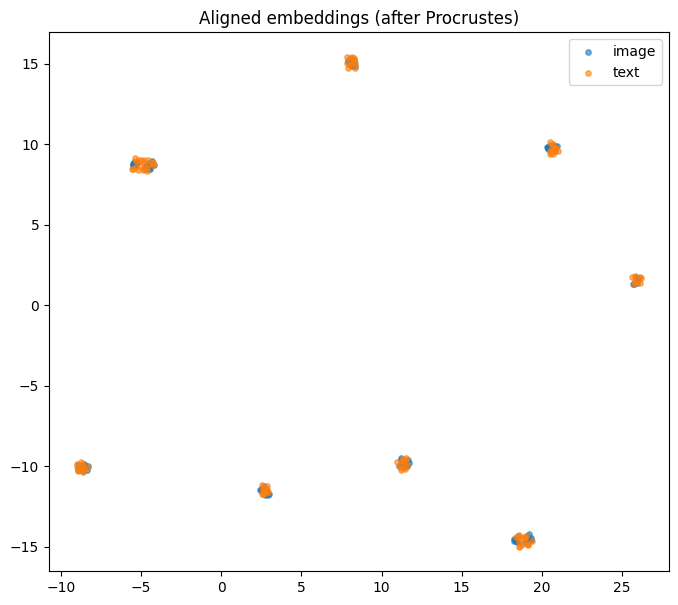

Modality gap (centroid distance) before alignment: 1.0495
Modality gap (centroid distance) after alignment:  0.1326


In [22]:

pair_image_embeds_n = F.normalize(pair_image_embeds, dim=-1).numpy()
pair_image_embeds_aligned = torch.from_numpy(pair_image_embeds_n @ R).float()

fig, ax = plt.subplots(figsize=(8, 7))
plot_modality_gap(ax, pair_image_embeds_aligned, F.normalize(pair_text_embeds, dim=-1), "Aligned embeddings (after Procrustes)")
plt.show()

gap_before = modality_gap_distance(pair_image_embeds, pair_text_embeds)
gap_after = modality_gap_distance(pair_image_embeds_aligned, pair_text_embeds)

print(f"Modality gap - centeroid distance before the alignment: {gap_before:.4f}")
print(f"Modality gap - centeroid distance after the alignment:  {gap_after:.4f}")

**Analytical questions (Task 3.3(e)/(f)):**

### Bridging the Modality Gap via Orthogonal Procrustes

**Empirical Results:**

* Centroid Distance: The centroid distance decrease from $\Delta_{\text{gap}} = 1.0495$ to $\Delta_{\text{aligned}} = 0.1326$ roughly an $87.3\%$ reduction in geometric separation.
* Zero-Shot Classification Accuracies:
  * Plain: $96.25\% \to 96.00\%$ ($\Delta = -0.25\%$)
  * Templated: $97.29\% \to 97.16\%$ ($\Delta = -0.13\%$)
  * Descriptive: $96.29\% \to 96.38\%$ ($\Delta = +0.09\%$)

**Formulation**

* The Orthogonal Procrustes Objective: For normalized paired matrices $X, Y \in \mathbb{R}^{K \times d}$, the alignment seeks an orthogonal transformation $R \in \mathcal{O}(d)$:

$$\min_{R \in \mathcal{O}(d)} \|XR - Y\|_F^2 \quad \text{subject to} \quad R^\top R = I_d$$

When we expand the Frobenius norm:

$$\|XR - Y\|_F^2 = \text{Tr}(X^\top X) + \text{Tr}(Y^\top Y) - 2\text{Tr}(R^\top X^\top Y)$$

Therefore, if $\text{Tr}(R^\top X^\top Y)$ is maximized via the Singular Value Decomposition (SVD) of $X^\top Y = U \Sigma V^\top$, we get the closed-form solution:

$$R^* = U V^\top$$

* Isometry and Invariance: Since $R \in \mathcal{O}(d)$, it is an isometry given as:

$$\|x R\|_2 = \|x\|_2 \quad \text{and} \quad \langle x_i R, x_j R \rangle = \langle x_i, x_j \rangle$$

* The SVD transformation ($R^* = U V^\top$) **bold text** solves the Procrustes problem to find the single global orientation. This transformation rotates the image embedding manifold as a rigid body onto the text cone. It minimizes absolute Euclidean distances $\|XR - Y\|_F$ by pulling the image vectors closer to their matched text counterparts and shrinking the centroid gap. This results in the centroid gap getting reduced from $1.0495$ to $0.1326$. The centroid (mean vector) represents the center of mass of each modality's embedding cone:

$$\mu_v = \frac{1}{N}\sum_{i=1}^N \hat{x}_i, \quad \mu_t = \frac{1}{N}\sum_{i=1}^N \hat{y}_i$$

  * Before Alignment ($\Delta_{\text{gap}} = 1.0495$): The image cone and text cone were entirely on different sectors on the unit hypersphere $\mathcal{S}^{511}$, resulting in two disjoint clusters with a large separation between their centers.
  * After Alignment ($\Delta_{\text{aligned}} = 0.1326$): $R$ rotated the image cloud toward the text cloud, making the centroid $\mu_v R$ alignment much closer to the text centroid $\mu_t$ by eliminating $\approx 87\%$ of the spatial distance between the two modalities.

* Performance Invariance Explanation: As in zero-shot classification we have rank-ordered cross-modal cosine similarity ($\arg\max_c \langle x R, y_c \rangle$), therefore when an isometric rotation is applied, it shifts the global manifold. This shift does not disturb the underlying angular separability among candidate classes. It shows that the absolute spatial proximity in representation space is decoupled from downstream zero-shot discriminability.